### Submission 1. Plotting learning curve

In [1]:
%reload_ext autoreload
%autoreload 2

In [6]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

from spyglass.shijiegu.Analysis_SGU import TrialChoice,EpochPos,MUA,get_linearization_map, ChangeofMind
from spyglass.shijiegu.decodeHelpers import runSessionNames
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename

from spyglass.shijiegu.behavior import (findSequence,
                      bootstrap_behavior,calculate_statistics,
                      findXCorrAllDays,
                      findSequenceMultiProcessing,find_behavior_transitions,normalize,matrix_correlation)

In [163]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}
peak_day_animal = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20220420'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110','20240113']
seq_animals[animal] = 'rev2'
peak_day_animal[animal] = '20240110'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20221024'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'
peak_day_animal[animal] = '20230811'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108','20231109','20231111']
seq_animals[animal] = 'rev2'
peak_day_animal[animal] = '20231108'

In [146]:
from spyglass.shijiegu.behavior import return_pctCorrect, find_COM_trials, plot_learning_curve

In [ ]:
pctCorrect_days, pctCorrect_days_sd, com_rates1, com_rates2, com_rates3 = {}, {}, {}, {}, {}

for animal in seq_animals.keys():
    days_to_plot = list_of_days_animals[animal]
    pctCorrect_days[animal], pctCorrect_days_sd[animal] = return_pctCorrect(animal, days_to_plot)
    com_rates1[animal] = find_COM_trials(animal,days_to_plot,proportion_threshold = 0.05)
    com_rates2[animal] = find_COM_trials(animal,days_to_plot,proportion_threshold = 0.1)
    com_rates3[animal] = find_COM_trials(animal,days_to_plot,proportion_threshold = 0.2)
    success_animal[animal] = 1

[2025-12-31 17:17:11,001][WARNING]: Skipped checksum for file with hash: 708f7a32-5e94-6c46-2e36-a8b3ce983a59, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_ZMQ61DATFR.nwb
[2025-12-31 17:17:22,723][WARNING]: Skipped checksum for file with hash: 5a494cee-2ce2-102d-c22e-02aadcfcfe55, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_YE5GQV4VCD.nwb
[2025-12-31 17:17:33,343][WARNING]: Skipped checksum for file with hash: 49f27511-efc3-fd4c-e00d-01b2a561a3b7, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_DME7M36ZVZ.nwb
[2025-12-31 17:17:46,038][WARNING]: Skipped checksum for file with hash: 75310ad9-e057-2cba-e824-8b1df6946470, and path: /stelmo/nwb/analysis/molly20220415/molly20220415_2W0TGBAQ7B.nwb
[2025-12-31 17:17:58,178][WARNING]: Skipped checksum for file with hash: 7dc6eca3-70d5-232d-7892-5f52e0e96a4b, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_A9HGPY6NT2.nwb
[2025-12-31 17:18:09,670][WARNING]: Skipped checksum for file with hash: f4

In [159]:
### save data
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
file_path = f"{output_folder}/figure1.pickle"

data = {"pctCorrect_days": pctCorrect_days, "pctCorrect_days_sd": pctCorrect_days_sd,
     "com_rates1": com_rates1, "com_rates2": com_rates2, "com_rates3": com_rates3}
with open(file_path, 'wb') as file:
    pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure1/figure1.pickle


### Plotting

In [171]:
data_folder = '/stelmo/shijie/change_of_mind_analysis/figure1'
file_path = f"{data_folder}/figure1.pickle"

with open(file_path, 'rb') as file:
    data = pickle.load(file)

pctCorrect_days, pctCorrect_days_sd = data["pctCorrect_days"], data["pctCorrect_days_sd"]
com_rates1, com_rates2, com_rates3 = data["com_rates1"], data["com_rates2"], data["com_rates3"]

[[0.6, 0.6, 0.6], 'C1', [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6], [0.6, 0.6, 0.6]]


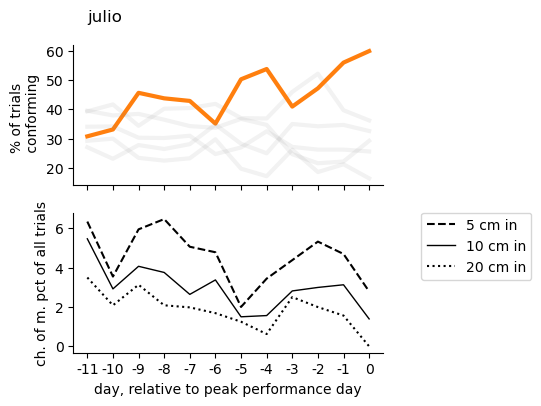

In [187]:
output_folder = '/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1'
animal = "julio"

if seq_animals[animal] == "rev2":
    target_seq_ind = 4
else:
    target_seq_ind = 1
        
plot_learning_curve(animal,
     pctCorrect_days[animal], pctCorrect_days_sd[animal],
     com_rates1[animal], com_rates2[animal], com_rates3[animal], peak_day_animal[animal],
     target_seq_ind, os.path.join(output_folder,f"Learning_curve_{animal}.pdf"))

## End here

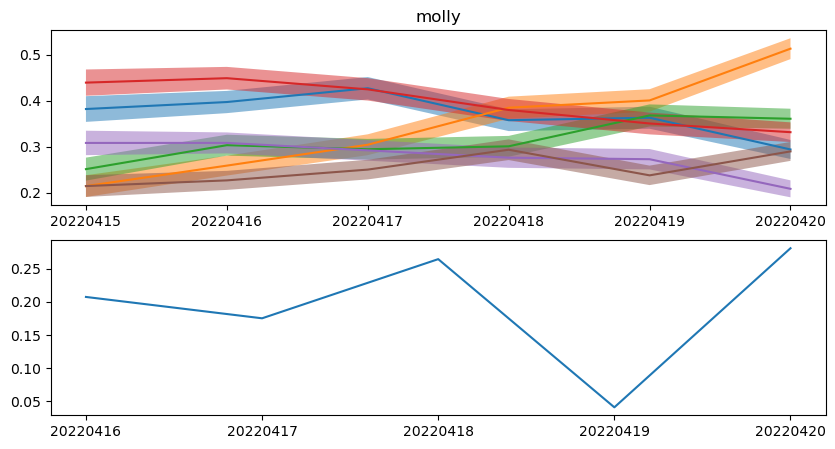

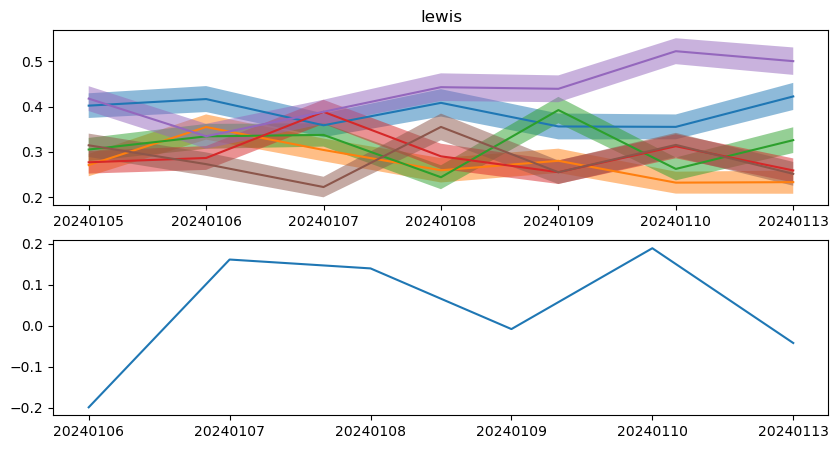

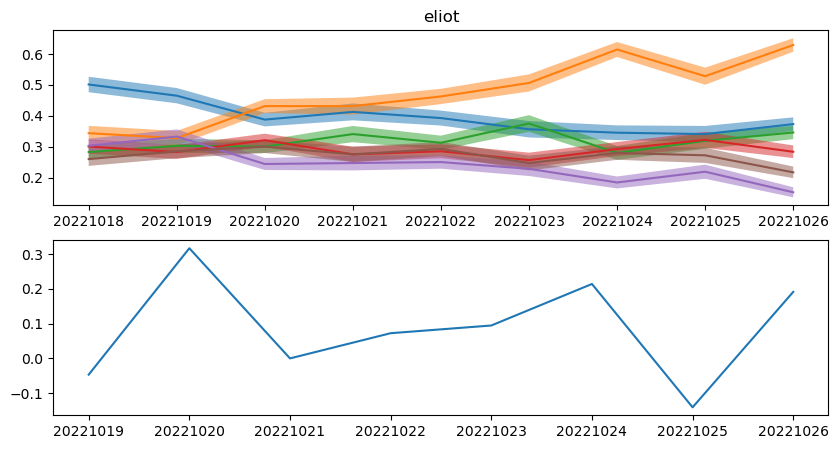

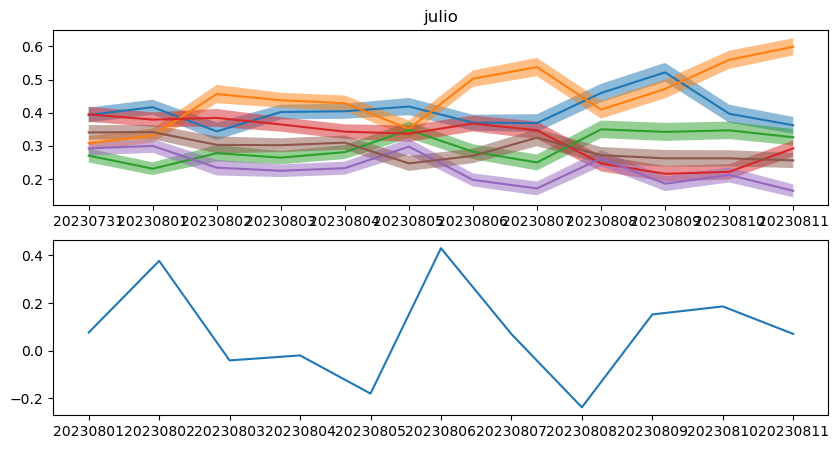

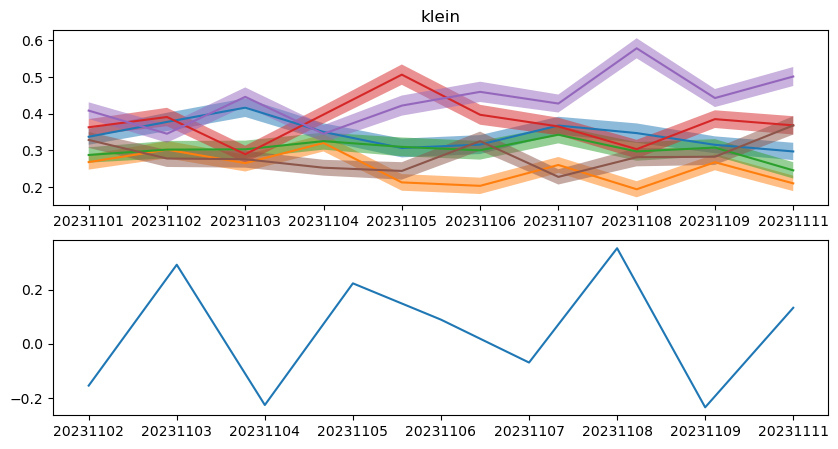

In [138]:
for animal in seq_animals.keys():
    mean_data = pctCorrect_days[animal]
    sd_data = pctCorrect_days_sd[animal]
    
    fig, axes = plt.subplots(2,1,figsize = (10,5))
    
    days = list(mean_data.keys())
    if seq_animals[animal] == "rev2":
        target_seq_ind = 4
    else:
        target_seq_ind = 1
        
    for seq_ind in range(6):
        y = np.array( [mean_data[k][seq_ind] for k in mean_data] )
        sd = np.array( [sd_data[k][seq_ind] for k in sd_data] )
        axes[0].plot(days, y)
        axes[0].fill_between(days, y - sd, y + sd, alpha = 0.5)
        
    y_taget = [mean_data[k][target_seq_ind] for k in mean_data]
    axes[1].plot(days[1:],np.diff(y_taget)/y_taget[:-1])
    axes[0].set_title(animal)


Once rat behavior becomes predominantly aligned with the correct sequence, we overtrain rats for another few days. 
We include all the data from early learning (1-2 days of low correct sequence transitions performance) to peak of performance day.